# EEE 2 Stage HPT 
EEE stands for Energy Efficient Engine, initiated in the mid-1970s, it was aimed at developing a more fuel efficient turbofan engine for commercial aviation. Both Pratt and Whitney and General Electric developed a version of the engine with components. The components are still used in simulations today as benchmark tools. 

The reports are in the eee_reference folder. GE developed a 2 stage HPT where Pratt developed a single stage. Most of the NASA reports and publications will reference the 2 stage HPT. The Geometry and simulation results were performed by Glenn and University of Cincinnati https://ntrs.nasa.gov/citations/20150003286

Simulations were done with Numeca CFD. Numeca can be expensive, their CFView Reader isn't free. In this tutorial, we perform simulations using ADS and release the Tecplot files of those simulations. The simulations were used to build a turbo-design model of the geometry using fixed pressure losses calculated from the simulation 

Total Pressure loss equation for a turbine. 01 denotes total pressure upstream of the blade row. 02 is downstream. P2 is the static pressure at blade row exit.
$$
    P_{0,loss} = \frac{P_{01} - P_{02}}{P_{01}-P_{2}}
$$



## EEE Boundary Conditions
|       **Inlet**      | **Units** | **Value** |
|:--------------------:|:---------:|:---------:|
| P0                   | Pa        | 1257514   |
| T0                   | K         | 1587      |
|      **Rotors**      |           |           |
| RPM                  |           | 12400     |
|      **Outlet**      |           |           |
| Exit Static Pressure | Pa        | 230300    |



|                      | **Stator-1** | **Rotor-1** | **Stator-2** | **Rotor-2** |
|:--------------------:|:------------:|:-----------:|:------------:|:-----------:|
| **Number of Blades** | 46           | 76          | 48           | 70          |

In [ ]:
!pip install turbo-design
!pip install pyiges[full]

# Import iges code
The code below imports and processes the hub, shroud, and blade iges files. 

In [1]:
import numpy as np
import os, pyiges, pickle
import matplotlib.pyplot as plt

def Process_HubShroud_IGES(): 
    """Exports hub and shroud curves in inches
    """
    iges_case = pyiges.read('case.igs')
    iges_hub = pyiges.read('hub.igs')

    # print an invidiual entity (boring)
    curve = iges_case.items[0].to_geomdl()
    case_pts = np.array(curve.evalpts)
    
    curve = iges_hub.items[0].to_geomdl()
    curve.delta=0.001
    hub_pts = np.array(curve.evalpts)
    os.makedirs('csv',exist_ok=True)

    np.savetxt('csv/shroud.csv',case_pts,fmt="%f",delimiter=',',header='x,r,theta')
    np.savetxt('csv/hub.csv',hub_pts,fmt="%f",delimiter=',',header='x,r,theta')

    plt.figure(num=0,figsize=(10,6))
    plt.plot(case_pts[:,0],case_pts[:,1])
    plt.plot(hub_pts[:,0],hub_pts[:,1])
    plt.axis('scaled')
    plt.savefig('flowpath.png',transparent=None,dpi=300)
    # Hub and Shroud are in inches
    pickle.dump({'Hub':hub_pts,'Shroud':case_pts},open('hub_shroud.pkl','wb'))

def Process_StatorRotor_IGES():
    """Exports stator and rotor curves in inches
    """
    # load an example impeller
    iges_rotor1 = pyiges.read('geometry/hpt_stator1.igs')
    iges_stator1 = pyiges.read('geometry/hpt_rotor1.igs')

    iges_rotor2 = pyiges.read('geometry/hpt_stator2.igs')
    iges_stator2 = pyiges.read('geometry/hpt_rotor2.igs')
    curve_delta=0.001
    # Stage 1 
    os.makedirs('csv',exist_ok=True)
    
    stator_pts1 = list(); indx = 1
    for i in range(2,7):
        curve = iges_stator1.items[i].to_geomdl()
        curve.delta=curve_delta
        points = np.array(curve.evalpts); n = points.shape[0]
        stator_pts1.append(points)
        os.makedirs('csv', exist_ok=True)
        np.savetxt(f'csv/stator1_{indx}.csv',points,fmt="%f",delimiter=',',header='x,rtheta,r')
        indx+=1
    
    # print an invidiual entity (boring)
    rotor_pts1 = list(); indx = 1
    for i in range(2,7):
        curve = iges_rotor1.items[i].to_geomdl()
        curve.delta=curve_delta
        points = np.array(curve.evalpts); 
        rotor_pts1.append(points)
        np.savetxt(f'csv/rotor1_{indx}.csv',points,fmt="%f",delimiter=',',header='x,rtheta,r')
        indx+=1

    # Stage 2
    stator_pts2 = list(); indx = 1 
    for i in range(2,6):
        curve = iges_stator2.items[i].to_geomdl()
        curve.delta=curve_delta
        points = np.array(curve.evalpts)
        stator_pts2.append(points)
        np.savetxt(f'csv/stator2_{indx}.csv',points,fmt="%f",delimiter=',',header='x,rtheta,r')
        indx+=1
    
    # print an invidiual entity (boring)
    rotor_pts2 = list(); indx = 1
    for i in range(2,7):
        curve = iges_rotor2.items[i].to_geomdl()
        curve.delta=curve_delta
        points = np.array(curve.evalpts)
        rotor_pts2.append(points)        
        np.savetxt(f'csv/rotor2_{indx}.csv',points,fmt="%f",delimiter=',',header='x,rtheta,r')
        indx+=1
    
    pickle.dump([stator_pts1,rotor_pts1,stator_pts2,rotor_pts2],open('stator_rotor.pkl','wb'))


### Lets import the IGES Geometry
The code below calls the functions required to import the hub and shroud curves from the iges files provided. The second function imports the blades from the iges files. 

In [2]:
from turbodesign import TurbineSpool, Inlet, RowType, BladeRow, Passage, Outlet, PassageType
from turbodesign.enums import MassflowConstraint
from turbodesign.coolant import Coolant
import platform

if platform.system() != "Darwin": # pyiges[full] does not work on MacOS        
    Process_HubShroud_IGES()        # units are in inches
    Process_StatorRotor_IGES()
    

## Processing the blade geometry
After the iges files have been imported they come as one single curve for the entire blade. It may become necessary to split the blade into suction and pressure side with equal number of points. Some CFD meshing tools require a split of suction and pressure sides in order to effectively generate the mesh for leading and trailing edge. 

Lets load the function below

In [4]:
import numpy.typing as npt
from scipy.interpolate import PchipInterpolator
from typing import List,Tuple

def fit_blade(hub:npt.NDArray,shroud:npt.NDArray,blades:List[Tuple[npt.NDArray,npt.NDArray]]):
    func_hub = PchipInterpolator(hub[:,0],hub[:,1]*0.99)
    func_shroud = PchipInterpolator(shroud[:,0],shroud[:,1]*1.01)
    
    for s,blade in enumerate(blades):
        ss = blade[0]
        ps = blade[1]
        for i in range(ss.shape[0]):
            ss[i,:,2] = ss[i,0,2]
            ps[i,:,2] = ss[i,0,2]
        
        max_index = np.argmax(ss[:,0,2])
        min_index = np.argmin(ss[:,0,2])
        height = ss[max_index,:,2] - ss[min_index,:,2]
        percent_hub_shroud = (ss[:,:,2]-ss[min_index,:,2])/height # Location of the profiles as a percentage of hub and shroud 
        for i in range(ss.shape[0]):
            for j in range(ss.shape[1]):
                ss[i,j,2] = (func_shroud(ss[i,j,0]) -  func_hub(ss[i,j,0])) * percent_hub_shroud[i,j] + func_hub(ss[i,j,0])
        
        max_index = np.argmax(ps[:,0,2])
        min_index = np.argmin(ps[:,0,2])
        height = ps[max_index,:,2] - ps[min_index,:,2]
        percent_hub_shroud = (ps[:,:,2]-ps[min_index,:,2])/height # Location of the profiles as a percentage of hub and shroud 
        for i in range(ps.shape[0]):
            for j in range(ps.shape[1]):
                ps[i,j,2] = (func_shroud(ps[i,j,0]) -  func_hub(ps[i,j,0])) * percent_hub_shroud[i,j] + func_hub(ps[i,j,0])
        
        min_to_max = np.argsort(ss[:,0,2])
        ss = ss[min_to_max,:,:]
        min_to_max = np.argsort(ps[:,0,2])
        ps = ps[min_to_max,:,:]
        
        # fig = plt.figure(num=1,clear=True,dpi=200,figsize=(10,6))
        # ax = fig.add_subplot(111, projection='3d')

        # for i in range(ss.shape[0]):
        #     ax.plot(ss[i,:,0],ss[i,:,1],ss[i,:,2],'.')
        #     ax.plot(ps[i,:,0],ps[i,:,1],ps[i,:,2],'.')
        #     ax.axis('equal')
        #     plt.savefig(f'fit_blade_{s}_section_{i}.jpg',dpi=150)

def plot_xz(hub:npt.NDArray,shroud:npt.NDArray,blades:List[npt.NDArray],plot_name:str=''):
    """_summary_

    Args:
        hub (npt.NDArray): _description_
        shroud (npt.NDArray): _description_
        blades (List[npt.NDArray]): _description_
    """
    # Plotting
    plt.figure(figsize=(10, 6))

    # Plot hub
    plt.plot(hub[:, 0], hub[:, 1], label='Hub', color='blue')

    # Plot shroud
    plt.plot(shroud[:, 0], shroud[:, 1], label='Shroud', color='red')

    # Plot blades (X-Z projection)
    for i, blade in enumerate(blades):
        ss = blade[0]
        ps = blade[1]
        for j in range(ss.shape[0]):  # m curves per blade
            x = ss[j, :, 0]
            z = ss[j, :, 2]
            plt.plot(x, z, '.',color='green', alpha=0.6)
            
        for j in range(ps.shape[0]):  # m curves per blade
            x = ps[j, :, 0]
            z = ps[j, :, 2]
            plt.plot(x, z, '.',color='blue', alpha=0.6)

    plt.xlabel('X')
    plt.ylabel('Z')
    plt.title('Blade, Hub, and Shroud in X-Z Plane')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')  # Equal aspect ratio
    plt.savefig(f'XZ - {plot_name}.jpg',dpi=300)
    plt.show()
        

In [5]:
# Load the processed data
blades = pickle.load(open('stator_rotor.pkl','rb'))


In [6]:
# Plot some of the profiles
print("number of blades " + str(len(blades))) # This is stator,rotor, stator,rotor

stator1 = blades[0]
rotor1 = blades[1]
stator2 = blades[2]
rotor2 = blades[3]

print(f'Number of sections for stator1: {len(stator1)}')
print(f'Number of points for each section of stator1: {stator1[0].shape[0]}')

number of blades 4
Number of sections for stator1: 5
Number of points for each section of stator1: 1000


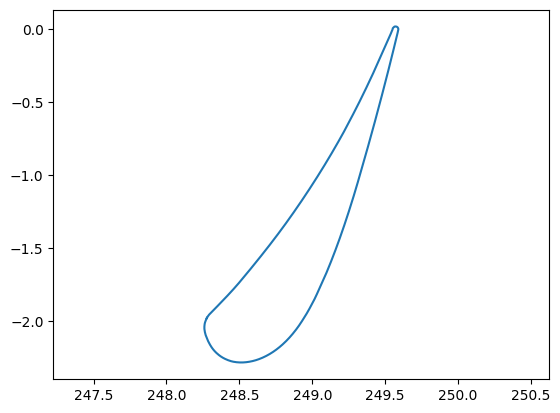

In [7]:
plt.figure()
plt.plot(stator1[0][:,0],stator1[0][:,1]) # X-Y plot of stator1
plt.axis('equal')
plt.show()
# Note the blade is a single continous section at a z value

In [8]:
from get_ss_ps import split_airfoil_by_angle_distance, resample_curve, plot_blade

processed_data = []
npts = 400
for i,blade in enumerate(blades):
    nsections = len(blade)
    n,m = blade[0].shape
    ss = np.zeros(shape=(nsections,npts,m))
    ps = np.zeros(shape=(nsections,npts,m))
    for section_index in range(nsections):
        ss_temp, ps_temp = split_airfoil_by_angle_distance(blade[section_index],npts=npts)
        # plot_blade(ss,ps,'test')
        ss[section_index,:,:] = ss_temp
        ps[section_index,:,:] = ps_temp
    ss = ss[np.argsort(ss[:,0,2]),:,:]
    ps = ps[np.argsort(ps[:,0,2]),:,:]
    ss *= 25.4 # convert to mm
    ps *= 25.4 # convert to mm
    print(f'Blade-{i} has {nsections} sections')
    processed_data.append((ss, ps))

hub_shroud = pickle.load(open('hub_shroud.pkl','rb'))
hub = resample_curve(hub_shroud['Hub'],200) * 25.4          # Convert in to mm
shroud = resample_curve(hub_shroud['Shroud'],200) * 25.4

Blade-0 has 5 sections
Blade-1 has 5 sections
Blade-2 has 4 sections
Blade-3 has 5 sections


Stator 1 suction side has 5 sections
Stator 1 pressure side has 5 sections

Stator 1 suction side section 0 has 400 points
Stator 1 pressure side section 0 has 400 points


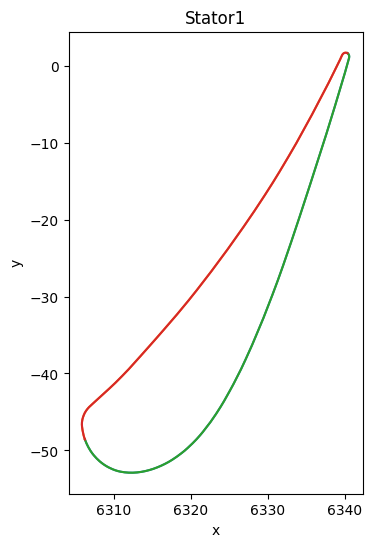

In [9]:
stator1 = processed_data[0]
print(f"Stator 1 suction side has {stator1[0].shape[0]} sections")
print(f"Stator 1 pressure side has {stator1[1].shape[0]} sections\n")

print(f"Stator 1 suction side section 0 has {stator1[0].shape[1]} points")
print(f"Stator 1 pressure side section 0 has {stator1[1].shape[1]} points")
plot_blade(stator1[0][0,:,:],stator1[1][0,:,:],'Stator1') # Stator 1 with equal number of suction and pressure side points 

In [10]:
# Resample the hub and shroud curves to include more points 
hub_shroud = pickle.load(open('hub_shroud.pkl','rb'))
hub = resample_curve(hub_shroud['Hub'],200) * 25.4      # Resample and convert in to mm
shroud = resample_curve(hub_shroud['Shroud'],200) * 25.4
    

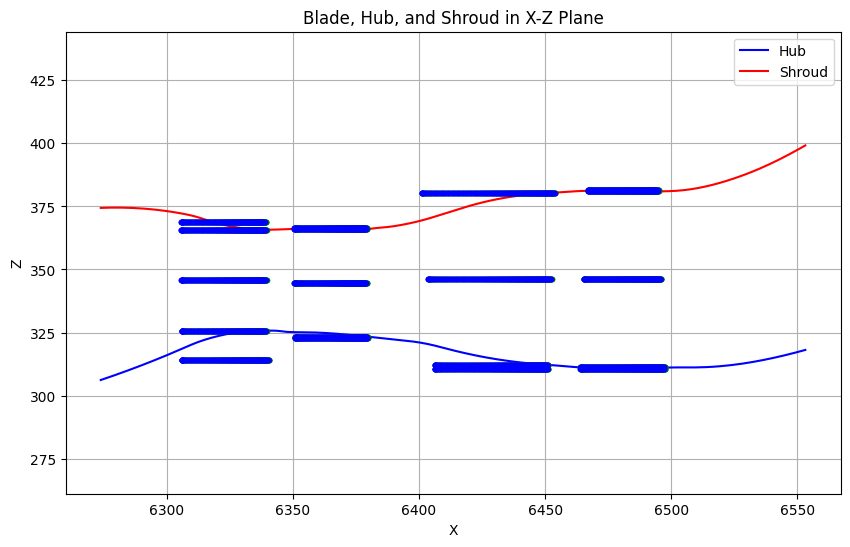

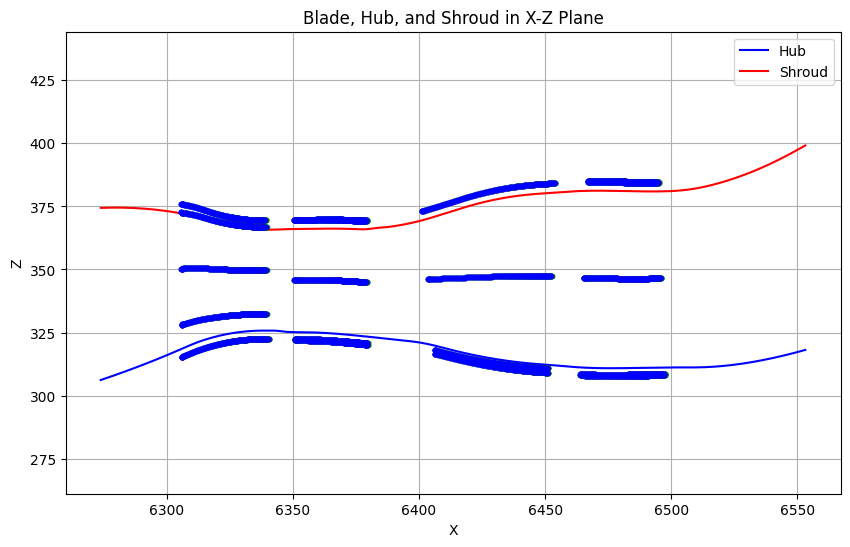

In [11]:
# Lets verify by plotting
plot_xz(hub,shroud,processed_data,'before fit')
fit_blade(hub,shroud,processed_data)            # Fit the blade into streamlines between hub and shroud
plot_xz(hub,shroud,processed_data, 'after fit')

## Creating the Aero Geometry File (AGF) 
AGF is needed by Aerodynamic solutions solver to generate the mesh. This tutorial demonstrate the code required to construct this file but will not cover the meshing and solving as this would require a license.

In [12]:
from agf import Inlet_bcs, Outlet_bcs, Settings, AGF_Setup, Clearance

# Output the AGF Files for ADS 
nblades = [46,76,48,70] # Vanes, Rotors, Vanes, Rotors
P0 = 1257514/1000       # kPa
T0 = 1587       # K
P = 230300/1000        # kPa

CorrectedSpeed = 33.19 # rad/(sec * sqrt(K))
RPM = 12400 # CorrectedSpeed * np.sqrt(T0) * 30/np.pi
RPM = [0,RPM,0,RPM]     # Stator - Rotor - Stator - Rotor
inlet = Inlet_bcs(ptin=P0,ttin=1588,machin=0.2,alpin=0,phiin=0,pspan=50)
clearance = Clearance(tlecl=0.000,tmccl=0.000,ttecl=0.000,hlecl=0,hmccl=0,htecl=0)

for i in range(len(processed_data)):
    ss = processed_data[i][0]; ps = processed_data[i][1]
    settings = Settings(ifang=0)
    settings.nblades = nblades[i]
    settings.ity = 5 # x,y,z
    settings.lete = 10 
    outlet = Outlet_bcs(rpm=RPM[i],gamma=1.3,
                    psout=P,twall=0,molwt=28.96)
    agf = AGF_Setup(template_file='template.agf',name=f"EEE-HPT-{i}")
    agf.add_inlet(inlet=inlet)
    agf.add_outlet(outlet=outlet)
    agf.add_clearance(clearance=clearance)
    agf.add_settings(settings=settings)

    # cen.plot()
    agf.add_passage(hub=hub, shroud=shroud)
    agf.add_blade(ss,ps)
    agf.build(output_filename=f'blade{i}.agf')


# Turbo Design Model


In [13]:
from turbodesign import TurbineSpool, Inlet, RowType, BladeRow, Passage, Outlet, PassageType
from turbodesign.enums import MassflowConstraint
from turbodesign.coolant import Coolant
from turbodesign.loss.turbine import FixedPressureLoss
import numpy as np
from cantera import Solution
import pickle
from scipy.interpolate import PchipInterpolator
# Geometry Import 
from get_ss_ps import split_airfoil_by_angle_distance, resample_curve, plot_blade

blades = pickle.load(open('stator_rotor.pkl','rb'))

processed_data = []
npts = 400
for i,blade in enumerate(blades):
    nsections = len(blade)
    n,m = blade[0].shape
    ss = np.zeros(shape=(nsections,npts,m))
    ps = np.zeros(shape=(nsections,npts,m))
    for section_index in range(nsections):
        ss_temp, ps_temp = split_airfoil_by_angle_distance(blade[section_index],npts=npts)
        # plot_blade(ss,ps,'test')
        ss[section_index,:,:] = ss_temp
        ps[section_index,:,:] = ps_temp
    ss = ss[np.argsort(ss[:,0,2]),:,:]
    ps = ps[np.argsort(ps[:,0,2]),:,:]
    ss *= 25.4 # convert to mm
    ps *= 25.4 # convert to mm
    print(f'Blade-{i} has {nsections} sections')
    processed_data.append((ss, ps))

hub_shroud = pickle.load(open('hub_shroud.pkl','rb'))
x = np.linspace(hub_shroud['Hub'][:,0].min(),hub_shroud['Hub'][:,0].max(),200)

hub = np.vstack([x,PchipInterpolator(hub_shroud['Hub'][:,0],hub_shroud['Hub'][:,1])(x)]).transpose()
hub *= 25.4          # Convert in to mm

shroud = np.vstack([x,PchipInterpolator(hub_shroud['Shroud'][:,0],hub_shroud['Shroud'][:,1])(x)]).transpose()
shroud *= 25.4 

# TurboDesign Setup 
nblades = [46,76,48,70] # Vanes, Rotors, Vanes, Rotors
P0 = 1257450        # Pa
T0 = 1587           # K
P = 230.295*1000    # Pa
n_streamlines = 5

# Fluid
fluid = Solution('air.yaml')
fluid.TP = T0, P0 # Use pascal for cantera
print(f"Coefficient of Pressure [J/Kg] {fluid.cp:0.4f}")
#%% Defining the Inlet
inlet = Inlet(M=0.1,
                 P0=[P0,P0],
                 T0=[T0,T0],
                 beta=[0,0],
                 percent_radii=[0,1],
                 location=0)
outlet = Outlet(P=P,percent_radii=[0.5],num_streamlines=n_streamlines)

Blade-0 has 5 sections
Blade-1 has 5 sections
Blade-2 has 4 sections
Blade-3 has 5 sections
Coefficient of Pressure [J/Kg] 1218.0291


Lets setup the loss. For this example the data for Total Pressure Loss was extracted from the NASA EEE 2-Stage HPT Tecplot Simulation Release. 
$$
    P_{0,Loss} = \frac{P_{01}-P_{02}}{P_{01}-P_{2}}
$$
where "0" denotes total condition. "01" refers to total condition upstream of the blade and 02 is downstream of the blade after the trailing edge. Single digit like "2" represent static condition.

In [16]:
beta_exit_flow = [73.6,-67.2,69.5,-63.9]
P0_Loss = [0.057,0.088,0.069,0.014]         # (P01-P02)/(P01-P2)

cax1 = processed_data[0][0][0,:,0].max()-processed_data[0][0][0,:,0].min()
cax2 = processed_data[1][0][0,:,0].max()-processed_data[1][0][0,:,0].min()
cax3 = processed_data[2][0][0,:,0].max()-processed_data[2][0][0,:,0].min()
cax4 = processed_data[3][0][0,:,0].max()-processed_data[3][0][0,:,0].min()
location1 = (processed_data[0][0][0,:,0].max() - hub[:,0].min()) / (hub[:,0].max()-hub[:,0].min())
location2 = (processed_data[1][0][0,:,0].max() - hub[:,0].min()) / (hub[:,0].max()-hub[:,0].min())
location3 = (processed_data[2][0][0,:,0].max() - hub[:,0].min()) / (hub[:,0].max()-hub[:,0].min())
location4 = (processed_data[3][0][0,:,0].max() - hub[:,0].min()) / (hub[:,0].max()-hub[:,0].min())
print(f'Stator 1 Axial Chord {cax1:0.2} mm')
print(f'Rotor 1 Axial Chord {cax2:0.2} mm')
print(f'Stator 2 Axial Chord {cax3:0.2} mm')
print(f'Rotor 2 Axial Chord {cax4:0.2} mm')

print(f'Stator 1 Exit Location along hub as percent {location1:0.2f}')
print(f'Rotor 1 Exit Location along hub as percent {location2:0.2f}')
print(f'Stator 2 Exit Location along hub as percent {location3:0.2f}')
print(f'Rotor 2 Exit Location along hub as percent {location4:0.2f}')


Stator 1 Axial Chord 3.4e+01 mm
Rotor 1 Axial Chord 2.9e+01 mm
Stator 2 Axial Chord 4.5e+01 mm
Rotor 2 Axial Chord 3.4e+01 mm
Stator 1 Exit Location along hub as percent 0.24
Rotor 1 Exit Location along hub as percent 0.38
Stator 2 Exit Location along hub as percent 0.64
Rotor 2 Exit Location along hub as percent 0.80


Looping to converge massflow
[0.505 0.505 0.505]
high massflow deviation detected
[0.506 0.505 0.505]
high massflow deviation detected
[0.505 0.506 0.505]
high massflow deviation detected
[0.505 0.505 0.506]
high massflow deviation detected
[0.06 0.06 0.06]
high massflow deviation detected
[0.41578115 0.41578115 0.41578115]
high massflow deviation detected
[0.4752477 0.4752477 0.4752477]
[0.4762477 0.4752477 0.4752477]
[0.4752477 0.4762477 0.4752477]
[0.4752477 0.4752477 0.4762477]
[0.06       0.23927495 0.95      ]
high massflow deviation detected
[0.39802489 0.4313643  0.56353647]
high massflow deviation detected
[0.45644108 0.46456047 0.49674928]
[0.46521144 0.4695444  0.48672214]
[0.46621144 0.4695444  0.48672214]
[0.46521144 0.4705444  0.48672214]
[0.46521144 0.4695444  0.48772214]
[0.06       0.91382474 0.2561985 ]
high massflow deviation detected
[0.41836625 0.52090623 0.46007204]
high massflow deviation detected
[0.45628119 0.47933568 0.48164174]
[0.45728119 0.47933568 0.481641

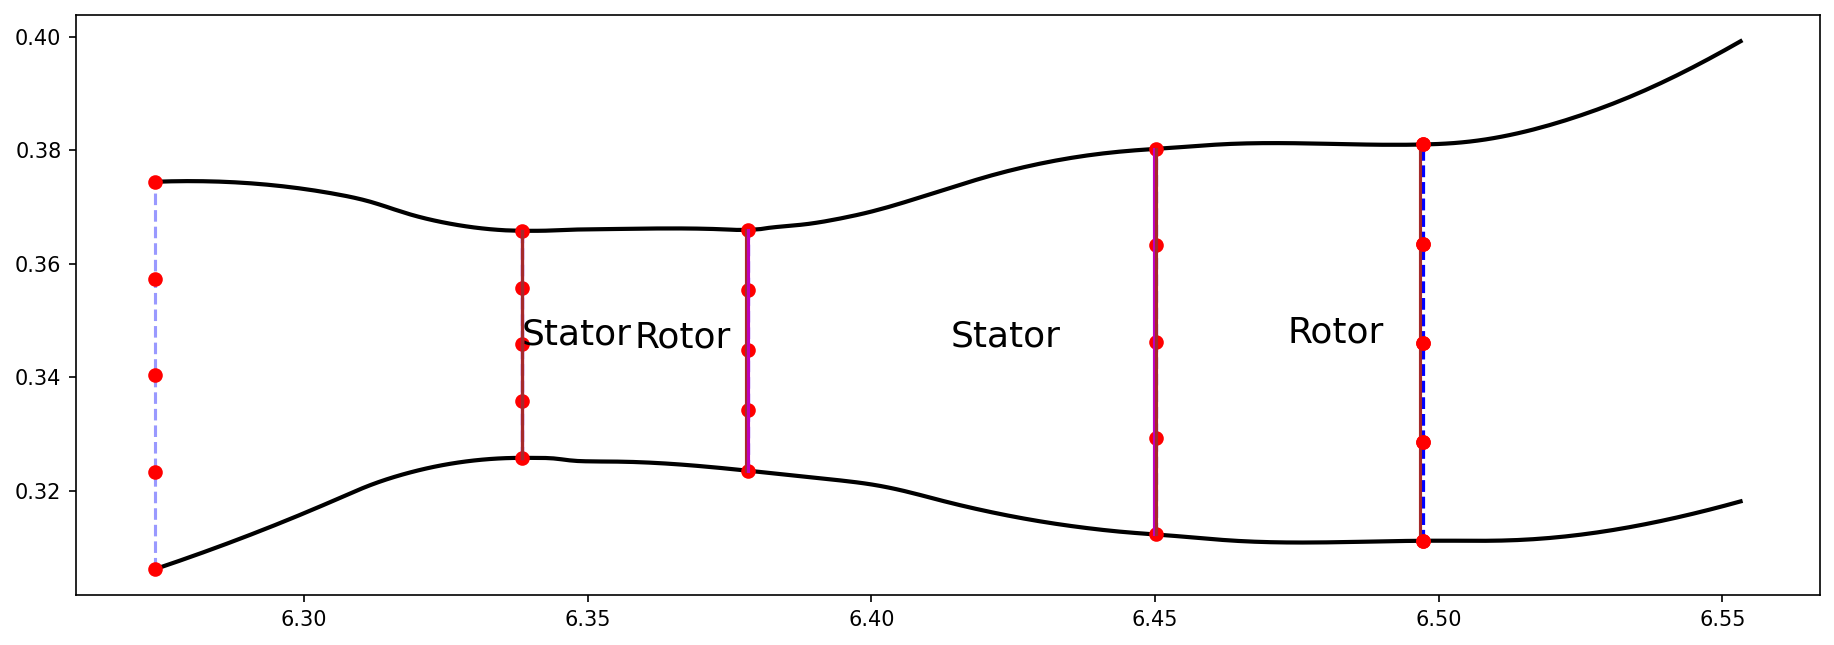

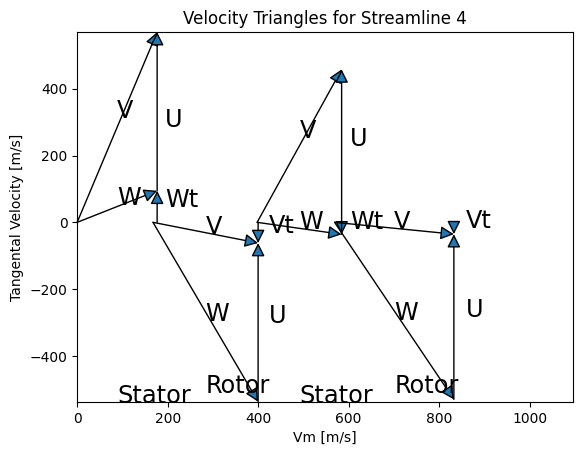

In [17]:
# Axial location is a percentage along the hub where row exit is defined
stator1 = BladeRow(row_type=RowType.Stator,location=location1)
rotor1 = BladeRow(row_type=RowType.Rotor, location=location2)
stator2 = BladeRow(row_type=RowType.Stator,location=location3)
rotor2 = BladeRow(row_type=RowType.Rotor, location=location4)

stator1.axial_chord = cax1 # Set an axial chord
rotor1.axial_chord = cax2
stator2.axial_chord = cax3
rotor2.axial_chord = cax4

inlet.gamma = 1.30
stator1.gamma = 1.30
rotor1.gamma = 1.32
stator2.gamma = 1.33
rotor2.gamma = 1.39

inlet.Cp = inlet.gamma/(inlet.gamma-1) * 287.15
stator1.Cp = stator1.gamma/(stator1.gamma-1) * 287.15
rotor1.Cp = rotor1.gamma/(rotor1.gamma-1) * 287.15
stator2.Cp = stator2.gamma/(stator2.gamma-1) * 287.15
rotor2.Cp = rotor2.gamma/(rotor2.gamma-1) * 287.15

stator1.stage_id = 0; rotor1.stage_id = 0
stator2.stage_id = 1; rotor2.stage_id = 1

# Coolant Definition: Use Kelvin and Pascal. Coolant only needs P0, T0, massflow, and Cp
stator1.coolant = Coolant(T0=T0*0.6, P0= P0, massflow_percentage=0,Cp=fluid.cp) 
rotor1.coolant = Coolant(T0=T0*0.6, P0=P0,massflow_percentage=0,Cp=fluid.cp)
stator2.coolant = Coolant(T0=T0*0.6, P0=P0, massflow_percentage=0,Cp=fluid.cp) 
rotor2.coolant = Coolant(T0=T0*0.6, P0=P0,massflow_percentage=0,Cp=fluid.cp)

# Add in turning angles
stator1.beta2_metal = [beta_exit_flow[0] for _ in range(n_streamlines)]        # Angle, hub,mean,tip
rotor1.beta2_metal = [beta_exit_flow[1] for _ in range(n_streamlines)]
stator2.beta2_metal = [beta_exit_flow[2] for _ in range(n_streamlines)]
rotor2.beta2_metal = [beta_exit_flow[3] for _ in range(n_streamlines)]


# These are all guessed values
stator1.loss_model = FixedPressureLoss(P0_Loss[0])  # type: ignore
rotor1.loss_model = FixedPressureLoss(P0_Loss[1])   # type: ignore
stator2.loss_model = FixedPressureLoss(P0_Loss[2])  # type: ignore
rotor2.loss_model = FixedPressureLoss(P0_Loss[3])   # type: ignore
hub_m = hub/1000
shroud_m = shroud/1000
passage = Passage(hub_m[:,0],hub_m[:,1],
                 shroud_m[:,0],shroud_m[:,1],
                 passageType=PassageType.Axial) # type: ignore

spool = TurbineSpool(passage=passage,
            rpm=12400, 
            num_streamlines=n_streamlines, 
            massflow=20, 
            fluid=None,
            rows=[inlet,stator1,rotor1,stator2,rotor2,outlet])
spool.massflow_constraint = MassflowConstraint.BalanceMassFlow # Fixes the exit angle and changes degree of reaction
spool.adjust_streamlines = False
spool.solve() # This also initializes streamlines
spool.export_properties("eee_results.json")
spool.plot()
spool.plot_velocity_triangles()